# Out Of Sample Back Test
This is a copy of the previous code to test on out of sample data, gaining a new sharpe ratio for conculsions look at the 'Conculsions' file.

In [16]:
import matplotlib.pyplot as plt
import pandas as pd   
import yfinance as yf
import numpy as np
import statsmodels.api as sm
from arch import arch_model

So

In [17]:
spx = yf.download("^GSPC", start="1995-01-01", end="2026-08-01")
vix = yf.download("^VIX", start="1995-01-01", end="2026-08-01")

prices_spx = spx["Close"].squeeze()
prices_vix = vix["Close"].squeeze()

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [18]:
log_return_daily = np.log(prices_spx).diff()
Kvar = (prices_vix / 100) ** 2 # Proxy for VIX
window = 21 # 21 trading days in a month

Iteration:      1,   Func. Count:      6,   Neg. LLF: 862188928964343.4
Iteration:      2,   Func. Count:     15,   Neg. LLF: 210940646.38505068
Iteration:      3,   Func. Count:     22,   Neg. LLF: 15328.481764155234
Iteration:      4,   Func. Count:     29,   Neg. LLF: 117279.9653930216
Iteration:      5,   Func. Count:     36,   Neg. LLF: 10932.280556637095
Iteration:      6,   Func. Count:     42,   Neg. LLF: 20444.868816557893
Iteration:      7,   Func. Count:     49,   Neg. LLF: 10859.015800331235
Iteration:      8,   Func. Count:     55,   Neg. LLF: 10841.901628271211
Iteration:      9,   Func. Count:     60,   Neg. LLF: 10841.882160758109
Iteration:     10,   Func. Count:     65,   Neg. LLF: 10841.88162363461
Iteration:     11,   Func. Count:     70,   Neg. LLF: 10841.881602638658
Iteration:     12,   Func. Count:     74,   Neg. LLF: 10841.881602641266
Optimization terminated successfully    (Exit mode 0)
            Current function value: 10841.881602638658
            Iterat

<Axes: >

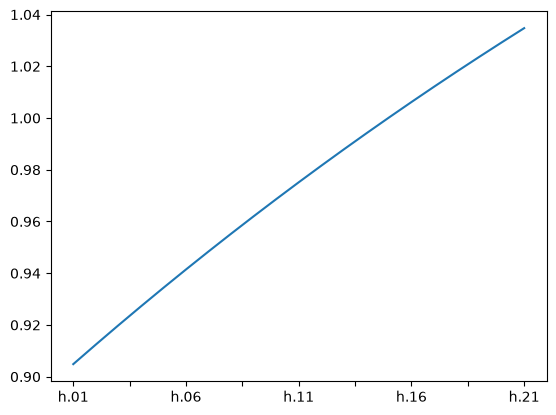

In [19]:
# Use GARCH to forecast variance, I am going to keep everything in variance points for now 
returns = 100 * prices_spx.pct_change().dropna()
model = arch_model(returns, vol='Garch', p=1, q=1, dist='normal')
result = model.fit()

forecast = result.forecast(horizon=21)
daily_var_forecast = forecast.variance.iloc[-1]
var_forecast = daily_var_forecast.sum()
daily_var_forecast.plot()


-20.39111866824073


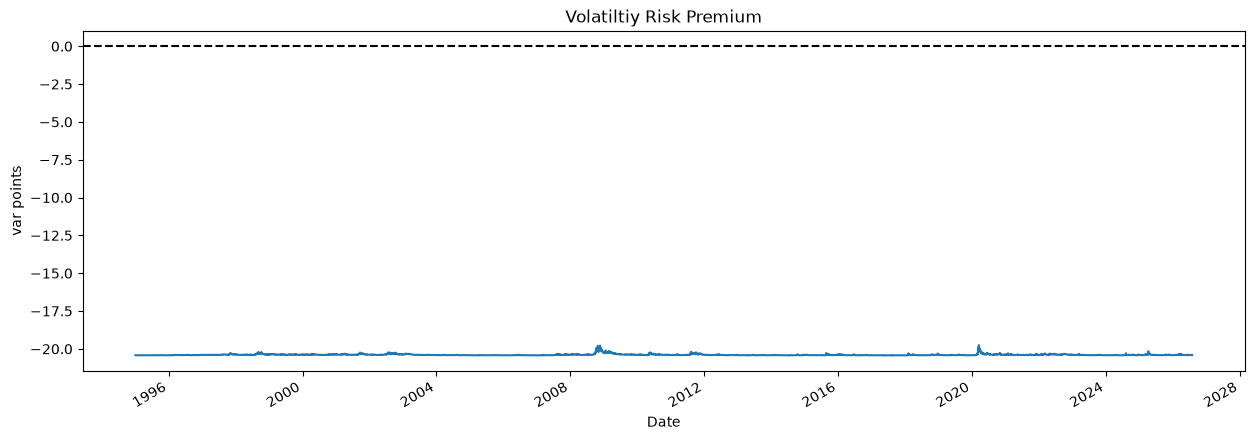

In [20]:
# Now we can define The Volatility Risk Premium
VRP = Kvar - var_forecast
print(VRP.mean())
VRP.plot(title='Volatiltiy Risk Premium',ylabel='var points', figsize=(15,5))
plt.axhline(0, linestyle = "--", color = 'black')

In [21]:
roll_VRP_mean = VRP.expanding(min_periods=252).mean()
roll_VRP_std = VRP.expanding(min_periods=252).std()

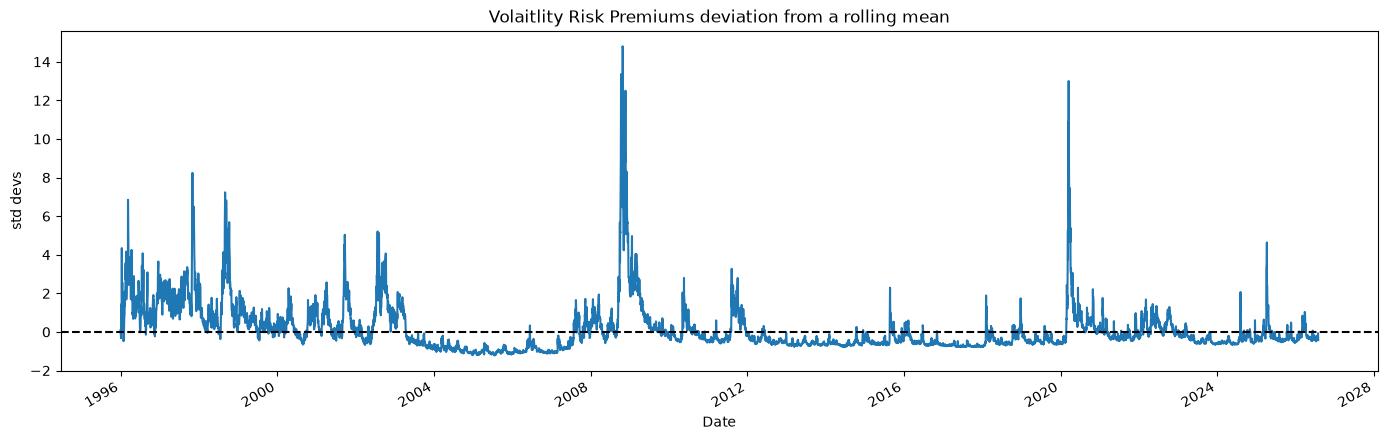

In [22]:
#now can make a z-score, assuming the VRP is mean reverting
VRP_z_score = ((VRP - roll_VRP_mean) / roll_VRP_std).dropna()
VRP_z_score.plot(title='Volaitlity Risk Premiums deviation from a rolling mean', ylabel='std devs', figsize=(17,5))
plt.axhline(0, linestyle = "--", color = 'black')

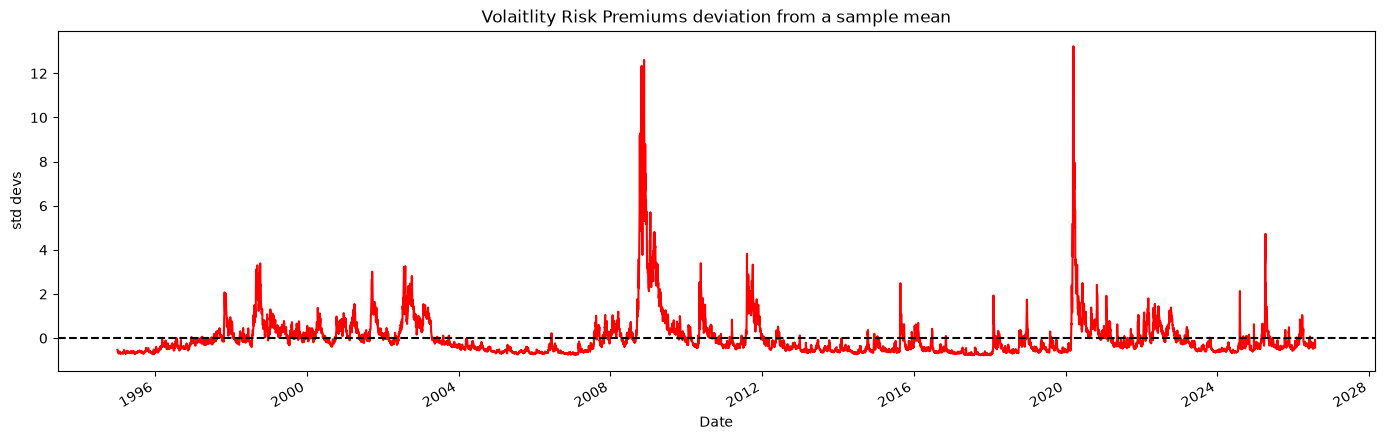

In [23]:
VRP_mean_z_score = ((VRP-VRP.mean())/ VRP.std()).dropna()
VRP_mean_z_score.plot(title='Volaitlity Risk Premiums deviation from a sample mean', ylabel='std devs', color='Red' , figsize=(17,5),)
plt.axhline(0, linestyle = "--", color = 'black')

In [35]:
# Here to show the difference between the in an out of sample data

VRP_IS_z = VRP_z_score[VRP_z_score.index >= "2011-01-01"]
print(VRP_IS_z)

Date
2011-01-03   -0.421208
2011-01-04   -0.435829
2011-01-05   -0.458360
2011-01-06   -0.434424
2011-01-07   -0.450749
                ...   
2026-07-27   -0.230736
2026-07-28   -0.265898
2026-07-29   -0.068400
2026-07-30   -0.347877
2026-07-31   -0.423317
Name: ^VIX, Length: 3918, dtype: float64


In [41]:
# Calculate for in sample 
position = 0
positions = [] #  currenlty have an empty book
entry_req = 1
Days_in_trade = 0
for z in VRP_IS_z:
    enter_position = 0 
    if position == 0:
        if z > entry_req:
            position = -1
            enter_position = -1
            Days_in_trade = 0
            
        elif z < - entry_req:
            position = 1
            entry_today = 1
            Trading_days = 0
    else:
        Days_in_trade += 1
        if Days_in_trade >= 30:
            position = 0 
            trading_days = 0 
    positions.append(enter_position)

print(len(positions))

3918


In [42]:
positions_series = pd.Series(positions, index= VRP_IS_z.index, name="Position")
Record_of_trades = positions_series[positions_series !=0]
print(len(Record_of_trades))

20


In [43]:
realised_var_30d = {}

for date in Record_of_trades.index:
    location = log_return_daily.index.get_loc(date)
    future_returns = log_return_daily.iloc[location + 1 : location + 1 + window]
    if len(future_returns) == window:
        realised_var_30d[date] = ((future_returns ** 2).sum()* (252 / window))
    else:
        realised_var_30d[date] = np.nan


<Axes: title={'center': 'Short Variance swap Returns In sample'}, xlabel='Date'>

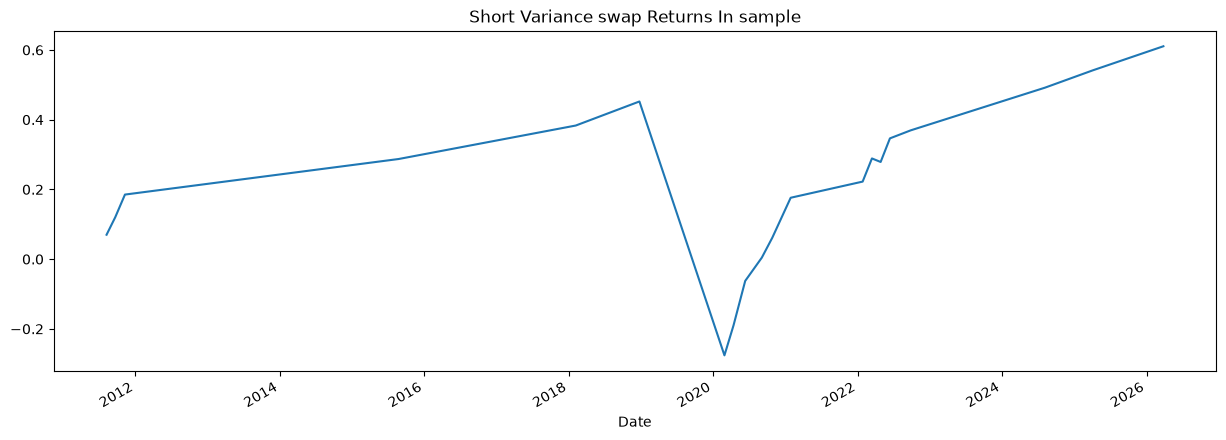

In [44]:
realised_var_30d = pd.Series(realised_var_30d, name="30 day realised variance")

payoff = Record_of_trades * (realised_var_30d - Kvar.loc[Record_of_trades.index])
cumlative_payoff = payoff.cumsum()
cumlative_payoff.plot(title="Short Variance swap Returns In sample",figsize=(15,5))




In [45]:
# sharpe 
mean_payoff = payoff.mean()
std_payoff =  payoff.std()
sharpe_per_payoff = mean_payoff / std_payoff
trades_per_year = len(payoff) / (len(VRP_IS_z)/252)
sharpe_annual = (sharpe_per_payoff * np.sqrt(trades_per_year)) 
print(sharpe_annual)

0.19074492187351091
